In [1]:
from ultralytics import YOLO
import tensorflow as tf
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

In [2]:
PATH_PT = "../models/yolov8n.pt"
PATH_ONNX = "../models/quantized_models/onnx/yolov8n_opset17_fp32.onnx"
PATH_DATASET = "../datasets/"
PATH_IMAGES = PATH_DATASET + "coco/images/"
PATH_VALIDATION_IMAGES = PATH_IMAGES + "val2017/"
FULL_PATH = PATH_VALIDATION_IMAGES + "000000000139.jpg"
# "/Users/helbuk/Documents/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/datasets/coco/images/val2017/000000000139.jpg"


In [3]:
y = YOLO("../models/yolov8n.pt")

In [4]:
model_eval = y.model.eval()
# model_eval

In [5]:
activations = {}
hooks = []
for i, layer in enumerate(model_eval.model):
        def make_hook(idx):
            def hook(module, inp, out):
                # store raw output (tensor or list/tuple)
                activations[idx] = out
            return hook
        hooks.append(layer.register_forward_hook(make_hook(i)))
_ = y.predict(source=FULL_PATH, verbose=False)
for h in hooks:
        h.remove()
rows = []
for i, layer in enumerate(model_eval.model):
    layer_name = f"{i:03d}_{layer.__class__.__name__}"
    out = activations.get(i, None)
    print(out)
    break

tensor([[[[ 1.7038e+01,  1.3481e+00,  1.3481e+00,  ...,  1.3481e+00,  1.3481e+00,  1.3481e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          ...,
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00],
          [ 1.9177e+01,  1.0259e+00,  1.0259e+00,  ...,  1.0259e+00,  1.0259e+00,  1.0259e+00]],

         [[-1.4360e-04, -4.9904e-05, -4.9904e-05,  ..., -4.9904e-05, -4.9904e-05, -4.9904e-05],
          [-4.9731e-04, -1.7957e-04, -1.7957e-04,  ..., -1.7957e-04, -1.7957e-04, -1.7957e-04],
          [-4.9731e-04, -1.7957e-04, -1.7957e-04,  ..., -1.7957e-04, -1.7957e-04, -1.7957e-04],
          ...,
          [-4.9731e-04, -1.7957e-04, -1.7957e-04,  ..., -1.7957e-04, -1.7957e-04, -1.7957e-04],
        

In [5]:
for i, layer in enumerate(model_eval.model):
    print(layer)

Conv(
  (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
Conv(
  (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
C2f(
  (cv1): Conv(
    (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), b

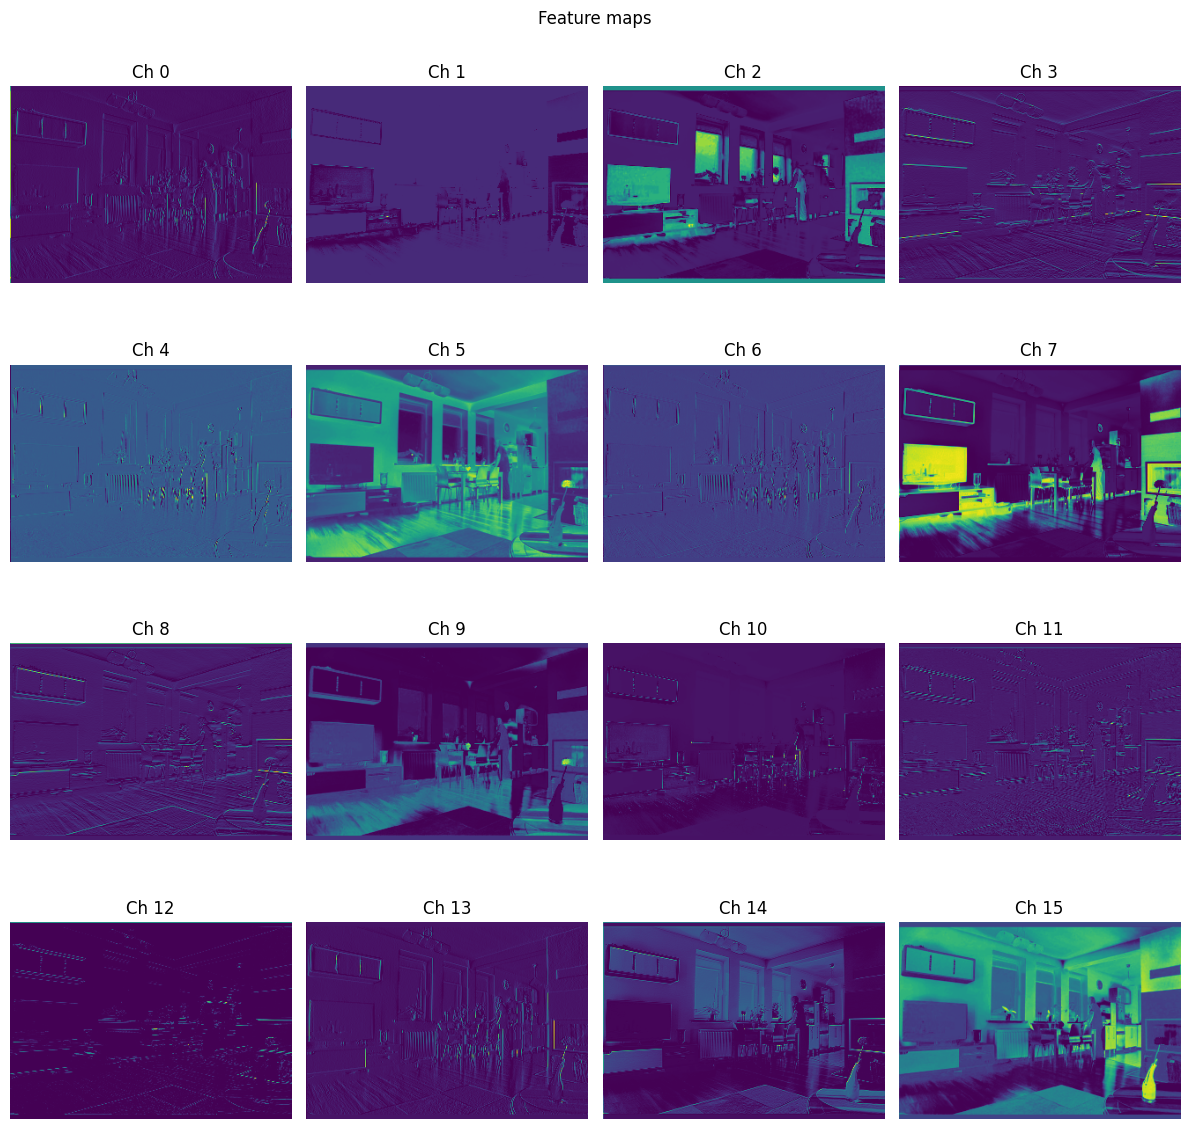

In [12]:
import matplotlib.pyplot as plt
import math

x = out[0]          # (C, H, W)
C = x.shape[0]
n = min(C, 16)      # show first 16 channels

cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 3, rows * 3))
for i in range(n):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x[i].cpu(), cmap="viridis")
    plt.title(f"Ch {i}")
    plt.axis("off")

plt.suptitle("Feature maps")
plt.tight_layout()
plt.show()

In [13]:
import torch
from ultralytics import YOLO

m = YOLO(PATH_PT).model
m.eval()

hooks = []

def hook_fn(i, layer):
    def hook(module, inp, out):
        # output shape
        if torch.is_tensor(out):
            out_shape = tuple(out.shape)
        elif isinstance(out, (list, tuple)) and out and torch.is_tensor(out[0]):
            out_shape = tuple(out[0].shape)
        else:
            out_shape = "unknown"

        # all parameters in this layer (including nested)
        params = list(layer.named_parameters(recurse=True))
        if not params:
            pinfo = "no-params"
        else:
            # show a few to keep it readable
            shown = ", ".join([f"{n}:{tuple(p.shape)}" for n, p in params[:4]])
            more = f" (+{len(params)-4} more)" if len(params) > 4 else ""
            pinfo = shown + more

        print(f"{i:03d} | {layer.__class__.__name__:12s} | out={out_shape} | params={pinfo}")
    return hook

for i, layer in enumerate(m.model):
    hooks.append(layer.register_forward_hook(hook_fn(i, layer)))

# one forward pass
m(torch.randn(1, 3, 640, 640))

for h in hooks:
    h.remove()

000 | Conv         | out=(1, 16, 320, 320) | params=conv.weight:(16, 3, 3, 3), bn.weight:(16,), bn.bias:(16,)
001 | Conv         | out=(1, 32, 160, 160) | params=conv.weight:(32, 16, 3, 3), bn.weight:(32,), bn.bias:(32,)
002 | C2f          | out=(1, 32, 160, 160) | params=cv1.conv.weight:(32, 32, 1, 1), cv1.bn.weight:(32,), cv1.bn.bias:(32,), cv2.conv.weight:(32, 48, 1, 1) (+8 more)
003 | Conv         | out=(1, 64, 80, 80) | params=conv.weight:(64, 32, 3, 3), bn.weight:(64,), bn.bias:(64,)
004 | C2f          | out=(1, 64, 80, 80) | params=cv1.conv.weight:(64, 64, 1, 1), cv1.bn.weight:(64,), cv1.bn.bias:(64,), cv2.conv.weight:(64, 128, 1, 1) (+14 more)
005 | Conv         | out=(1, 128, 40, 40) | params=conv.weight:(128, 64, 3, 3), bn.weight:(128,), bn.bias:(128,)
006 | C2f          | out=(1, 128, 40, 40) | params=cv1.conv.weight:(128, 128, 1, 1), cv1.bn.weight:(128,), cv1.bn.bias:(128,), cv2.conv.weight:(128, 256, 1, 1) (+14 more)
007 | Conv         | out=(1, 256, 20, 20) | params=conv.

In [10]:
import math
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from ultralytics import YOLO


# ---- config ----
MODEL_PATH = PATH_PT
IMAGE_PATH = FULL_PATH
PDF_PATH = Path("./pdfs/yolov8n_activations.pdf")
IMG_SIZE = 640
MAX_CH = 16
COLS = 4
DPI = 150


def first_tensor(obj):
    if torch.is_tensor(obj):
        return obj
    if isinstance(obj, dict):
        for v in obj.values():
            t = first_tensor(v)
            if t is not None:
                return t
    if isinstance(obj, (list, tuple)):
        for v in obj:
            t = first_tensor(v)
            if t is not None:
                return t
    return None


def stats_line(x: torch.Tensor) -> str:
    x = x.detach()
    xf = x.float()
    return (
        f"shape={tuple(x.shape)} dtype={x.dtype} "
        f"min={xf.min().item():.4g} max={xf.max().item():.4g} "
        f"mean={xf.mean().item():.4g} std={xf.std(unbiased=False).item():.4g}"
    )


def save_activation_page(pdf: PdfPages, layer_name: str, x: torch.Tensor):
    x = x.detach()
    if x.is_cuda:
        x = x.cpu()
    if x.dtype in (torch.float16, torch.bfloat16):
        x = x.float()

    # Render a grid of feature maps when possible
    if x.ndim == 4:          # (N,C,H,W)
        x0 = x[0]
        C = x0.shape[0]
        n = min(C, MAX_CH)
        rows = math.ceil(n / COLS)

        fig = plt.figure(figsize=(COLS * 3, rows * 3), dpi=DPI)
        fig.suptitle(f"{layer_name}\n{stats_line(x)}", fontsize=10)

        for i in range(n):
            ax = fig.add_subplot(rows, COLS, i + 1)
            ax.imshow(x0[i].numpy(), cmap="viridis")
            ax.set_title(f"ch {i}", fontsize=8)
            ax.axis("off")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)
        return


    # Fallback: histogram of flattened values
    xf = x.float().flatten()
    if xf.numel() > 2_000_000:
        xf = xf[:: max(1, xf.numel() // 2_000_000)]

    fig = plt.figure(figsize=(8, 4), dpi=DPI)
    ax = fig.add_subplot(1, 1, 1)
    ax.hist(xf.numpy(), bins=120)
    ax.set_title(f"{layer_name}\n{stats_line(x)}\n(hist of flattened values)", fontsize=9)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


# ---- main ----
y = YOLO(MODEL_PATH)
m = y.model
m.eval()

layers = list(m.model)  # Ultralytics sequential layer list

with PdfPages(str(PDF_PATH)) as pdf:
    hooks = []

    def make_hook(i, layer):
        lname = f"{i:03d} | {layer.__class__.__name__}"
        def hook(module, inp, out):
            t = first_tensor(out)
            if t is None:
                # still add a note page
                fig = plt.figure(figsize=(8, 2), dpi=DPI)
                ax = fig.add_subplot(1, 1, 1)
                ax.text(0.02, 0.6, f"{lname}\n(no tensor output)", fontsize=10)
                ax.axis("off")
                pdf.savefig(fig)
                plt.close(fig)
                return
            save_activation_page(pdf, lname, t)
        return hook

    for i, layer in enumerate(layers):
        hooks.append(layer.register_forward_hook(make_hook(i, layer)))

    # one forward pass (no need for an image file)
    with torch.no_grad():
         _ = y.predict(source=IMAGE_PATH, imgsz=640, rect=False, verbose=False)

    for h in hooks:
        h.remove()

print(f"Wrote: {PDF_PATH.resolve()}")

Wrote: /Users/helbuk/Documents/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/src/quantization/pdfs/yolov8n_activations.pdf


In [11]:
from __future__ import annotations

import argparse
import glob
from pathlib import Path

import numpy as np
import tensorflow as tf
import cv2
from ultralytics import YOLO


In [12]:
def convert_tflite_fp32(saved_model_dir: str, out_fp32: str):
    out_fp32 = str(Path(out_fp32))
    converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
    tflite_model = converter.convert()
    Path(out_fp32).parent.mkdir(parents=True, exist_ok=True)
    Path(out_fp32).write_bytes(tflite_model)
    return out_fp32

In [ ]:
import random
import shutil
from pathlib import Path

random.seed(42)

PATH = "../datasets/"
src = Path(PATH + "/coco/train/images/")
dst = Path(PATH + "coco_subset/train_1percent/images")
print(f"src: {src}")
print(f"dst: {dst}")
dst.mkdir(parents=True, exist_ok=True)

imgs = list(src.glob("*.jpg"))
subset = random.sample(imgs, int(len(imgs) * 0.01))  # 1%
print(len(subset))

for img in subset:
    shutil.copy(img, dst / img.name)

src: /Users/helbuk/Documents/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco/train/images
dst: /Users/helbuk/Documents/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco_subset/train_1percent/images
1182


In [ ]:
PATH_CALIB_DATA = "../datasets/coco_subset/train_0_1percent/coco_subset.yaml"
# Load the YOLO model
model = YOLO(PATH_PT)

# Export the model to TFLite format
model.export(format="tflite", imgsz=640, int8=True, nms=False, data=PATH_CALIB_DATA, device='cpu', split="train", simplify=True, opset=17, verbose=True) 

Ultralytics 8.4.6 🚀 Python-3.11.14 torch-2.9.1 CPU (Apple M3 Pro)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from '../../models/yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/Users/helbuk/Documents/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco_subset/train_0_1percent/coco_subset.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 445.3±293.7 MB/s, size: 165.9 KB)
Scanning /Users/helbuk/Documents/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/datasets/coco_subset/train_1percent/labels.cache... 0 images, 2472 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2472/2472 797.6Mit/s 0.0s
WARNING ⚠️ Labels are miss

I0000 00:00:1772897738.214817 29848680 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1772897738.216140 29848680 single_machine.cc:376] Starting new session
W0000 00:00:1772897738.674060 29848680 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772897738.674077 29848680 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1772897739.016257 29848680 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1772897739.016328 29848680 single_machine.cc:376] Starting new session
W0000 00:00:1772897739.387884 29848680 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772897739.387895 29848680 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1772897739.629508 29848680 devices.cc:76] 

W0000 00:00:1772897787.258973 29848680 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772897787.260278 29848680 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1772900261.514488 29848680 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772900261.514796 29848680 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1772902691.586955 29848680 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772902691.587275 29848680 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
W0000 00:00:1772907536.019771 29848680 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772907536.020570 29848680 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency

TensorFlow SavedModel: export success ✅ 14768.9s, saved as '../../models/yolov8n_saved_model' (40.8 MB)

TensorFlow Lite: starting export with tensorflow 2.20.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '../../models/yolov8n_saved_model/yolov8n_int8.tflite' (3.3 MB)

Export complete (14769.1s)
Results saved to /Users/helbuk/Documents/NTNU_Thesis_2026/Compiler-Aware_Model_Optimization/Thesis_Compiler_Aware_Model_Optimization_2026/thesis2026-project/src/models
Predict:         yolo predict task=detect model=../../models/yolov8n_saved_model/yolov8n_int8.tflite imgsz=640 int8
Validate:        yolo val task=detect model=../../models/yolov8n_saved_model/yolov8n_int8.tflite imgsz=640 data=coco.yaml int8 
Visualize:       https://netron.app


'../../models/yolov8n_saved_model/yolov8n_int8.tflite'

In [ ]:
import tensorflow as tf

Path = '../models/quantized_models/yolov8n_tflite_int8/'

interpreter = tf.lite.Interpreter(Path + "yolov8n_int8.tflite")
interpreter.allocate_tensors()

for d in interpreter.get_tensor_details():
    print(d["name"], d["dtype"])

images <class 'numpy.float32'>
arith.constant <class 'numpy.int32'>
arith.constant1 <class 'numpy.int32'>
arith.constant2 <class 'numpy.int32'>
arith.constant3 <class 'numpy.float32'>
arith.constant4 <class 'numpy.int32'>
arith.constant5 <class 'numpy.float32'>
arith.constant6 <class 'numpy.int32'>
arith.constant7 <class 'numpy.int32'>
arith.constant8 <class 'numpy.int32'>
arith.constant9 <class 'numpy.int32'>
arith.constant10 <class 'numpy.int32'>
arith.constant11 <class 'numpy.int32'>
arith.constant12 <class 'numpy.int32'>
arith.constant13 <class 'numpy.int32'>
arith.constant14 <class 'numpy.float32'>
arith.constant15 <class 'numpy.int32'>
arith.constant16 <class 'numpy.float32'>
arith.constant17 <class 'numpy.float32'>
arith.constant18 <class 'numpy.float32'>
arith.constant19 <class 'numpy.float32'>
arith.constant20 <class 'numpy.float32'>
arith.constant21 <class 'numpy.float32'>
arith.constant22 <class 'numpy.int32'>
arith.constant23 <class 'numpy.float32'>
arith.constant24 <class 

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [90]:
interpreter = tf.lite.Interpreter(Path + "yolov8n_full_integer_quant.tflite")
interpreter.allocate_tensors()

for d in interpreter.get_tensor_details():
    print(d["name"], d["dtype"])

serving_default_images:0 <class 'numpy.int8'>
arith.constant <class 'numpy.int32'>
arith.constant1 <class 'numpy.int32'>
arith.constant2 <class 'numpy.int32'>
arith.constant3 <class 'numpy.int32'>
arith.constant4 <class 'numpy.int32'>
arith.constant5 <class 'numpy.int32'>
arith.constant6 <class 'numpy.int32'>
arith.constant7 <class 'numpy.int32'>
arith.constant8 <class 'numpy.int32'>
arith.constant9 <class 'numpy.int32'>
arith.constant10 <class 'numpy.int32'>
arith.constant11 <class 'numpy.int32'>
arith.constant12 <class 'numpy.int32'>
arith.constant13 <class 'numpy.int32'>
arith.constant14 <class 'numpy.int32'>
arith.constant15 <class 'numpy.int32'>
arith.constant16 <class 'numpy.int32'>
arith.constant17 <class 'numpy.int32'>
arith.constant18 <class 'numpy.int32'>
arith.constant19 <class 'numpy.int32'>
arith.constant20 <class 'numpy.int32'>
arith.constant21 <class 'numpy.int32'>
arith.constant22 <class 'numpy.int32'>
arith.constant23 <class 'numpy.int32'>
arith.constant24 <class 'nump

In [ ]:
# # Load the exported TFLite model
# tflite_model = YOLO(SAVE_TO + "yolov8n_int8_20_percent_calib_640imgsz.tflite")

# # Run inference
# results = tflite_model(IMG_EXAMPLE)
# results

In [ ]:
import onnx
from collections import Counter

m = onnx.load("../models/quantized_models/onnx/yolov8n_opset17_int8_qop.onnx")
ops = Counter(n.op_type for n in m.graph.node)
print(ops.most_common(30))

In [2]:
# Small PyTorch-only pruning example on YOLOv8 (channel pruning by masking)

from ultralytics import YOLO
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch

y = YOLO("../models/yolov8n.pt")
model = y.model.eval()

In [7]:
model

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [3]:
# Prune first 8 standard Conv2d layers (skip Detect head and grouped/depthwise convs)
targets = []
for name, m in model.named_modules():
    if isinstance(m, nn.Conv2d) and not name.startswith("model.22"):
        targets.append((name, m))
targets

[('model.0.conv',
  Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)),
 ('model.1.conv',
  Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)),
 ('model.2.cv1.conv',
  Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.2.cv2.conv',
  Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.2.m.0.cv1.conv',
  Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)),
 ('model.2.m.0.cv2.conv',
  Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)),
 ('model.3.conv',
  Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)),
 ('model.4.cv1.conv',
  Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.4.cv2.conv',
  Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.4.m.0.cv1.conv',
  Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)),
 ('model.4.m.0.cv2.conv'

In [ ]:
def _detect_layer_idx(model: nn.Module) -> int | None:
    for i, m in enumerate(model.model):
        if m.__class__.__name__.lower() == "detect":
            return i
    return None

def _first_wrapper_with_conv(mod: nn.Module) -> nn.Module | None:
    if hasattr(mod, "conv") and isinstance(mod.conv, nn.Conv2d):
        return mod
    for ch in mod.children():
        print(ch)
        w = _first_wrapper_with_conv(ch)
        if w is not None:
            return w
    return None

def _block_output_wrapper(block: nn.Module) -> nn.Module | None:
    cls = block.__class__.__name__.lower()
    if cls in {"c2f", "sppf"} and hasattr(block, "cv2"):
        return _first_wrapper_with_conv(block.cv2)
    return _first_wrapper_with_conv(block)


def build_output_target_table(model: nn.Module) -> dict[str, int]:
    name_of = {id(m): n for n, m in model.named_modules()}
    table: dict[str, int] = {}
    det_i = _detect_layer_idx(model)

    for i, block in enumerate(model.model):
        if det_i is not None and i == det_i:
            continue
        w = _block_output_wrapper(block)
        if w is None or not hasattr(w, "conv") or not isinstance(w.conv, nn.Conv2d):
            continue
        if w.conv.groups != 1:
            continue

        p = name_of.get(id(w), f"model.{i}")
        if det_i is not None and p.startswith(f"model.{det_i}."):
            continue
        table[p] = i
    return table

out_table = build_output_target_table(model)

{'model.0': 0,
 'model.1': 1,
 'model.2.cv2': 2,
 'model.3': 3,
 'model.4.cv2': 4,
 'model.5': 5,
 'model.6.cv2': 6,
 'model.7': 7,
 'model.8.cv2': 8,
 'model.9.cv2': 9,
 'model.12.cv2': 12,
 'model.15.cv2': 15,
 'model.16': 16,
 'model.18.cv2': 18,
 'model.19': 19,
 'model.21.cv2': 21}

In [55]:
for i, m in enumerate(model.model):
    cls = m.__class__.__name__.lower()
    print(cls)

conv
conv
c2f
conv
c2f
conv
c2f
conv
c2f
sppf
upsample
concat
c2f
upsample
concat
c2f
conv
concat
c2f
conv
concat
c2f
detect


In [58]:
def _sources(i: int, layer: nn.Module) -> list[int]:
    f = getattr(layer, "f", -1)
    refs = [f] if isinstance(f, int) else list(f)
    return [i - 1 if r == -1 else int(r) for r in refs]

def _build_old_out_channels(layers: nn.Sequential, model_in_ch: int = 3) -> dict[int, int]:
    old_out: dict[int, int] = {}
    for i, m in enumerate(layers):
        cls = m.__class__.__name__.lower()
        src = _sources(i, m)

        if cls == "concat":
            old_out[i] = int(sum(old_out[s] for s in src))
            continue
        if cls in {"upsample", "split"}:
            old_out[i] = int(old_out[src[0]])
            continue
        if cls == "detect":
            old_out[i] = int(sum(old_out[s] for s in src))
            continue

        w = _block_output_wrapper(m)
        if w is not None and hasattr(w, "conv") and isinstance(w.conv, nn.Conv2d):
            old_out[i] = int(w.conv.out_channels)
        else:
            old_out[i] = int(model_in_ch if not src else sum(old_out[s] for s in src))
    return old_out

old_out = _build_old_out_channels(model.model, model_in_ch=3)
old_out

{0: 16,
 1: 32,
 2: 32,
 3: 64,
 4: 64,
 5: 128,
 6: 128,
 7: 256,
 8: 256,
 9: 256,
 10: 256,
 11: 384,
 12: 128,
 13: 128,
 14: 192,
 15: 64,
 16: 64,
 17: 192,
 18: 128,
 19: 128,
 20: 384,
 21: 256,
 22: 448}

In [34]:
named = dict(model.named_modules())
named.keys()

dict_keys(['', 'model', 'model.0', 'model.0.conv', 'model.0.bn', 'model.0.act', 'model.1', 'model.1.conv', 'model.1.bn', 'model.2', 'model.2.cv1', 'model.2.cv1.conv', 'model.2.cv1.bn', 'model.2.cv2', 'model.2.cv2.conv', 'model.2.cv2.bn', 'model.2.m', 'model.2.m.0', 'model.2.m.0.cv1', 'model.2.m.0.cv1.conv', 'model.2.m.0.cv1.bn', 'model.2.m.0.cv2', 'model.2.m.0.cv2.conv', 'model.2.m.0.cv2.bn', 'model.3', 'model.3.conv', 'model.3.bn', 'model.4', 'model.4.cv1', 'model.4.cv1.conv', 'model.4.cv1.bn', 'model.4.cv2', 'model.4.cv2.conv', 'model.4.cv2.bn', 'model.4.m', 'model.4.m.0', 'model.4.m.0.cv1', 'model.4.m.0.cv1.conv', 'model.4.m.0.cv1.bn', 'model.4.m.0.cv2', 'model.4.m.0.cv2.conv', 'model.4.m.0.cv2.bn', 'model.4.m.1', 'model.4.m.1.cv1', 'model.4.m.1.cv1.conv', 'model.4.m.1.cv1.bn', 'model.4.m.1.cv2', 'model.4.m.1.cv2.conv', 'model.4.m.1.cv2.bn', 'model.5', 'model.5.conv', 'model.5.bn', 'model.6', 'model.6.cv1', 'model.6.cv1.conv', 'model.6.cv1.bn', 'model.6.cv2', 'model.6.cv2.conv', 'mo

In [44]:
for raw in [x.strip() for x in "model.2.cv2".split(",") if x.strip()]:
    def _norm_target(t: str) -> str:
        t = t.strip().replace("model.model[", "model.").replace("]", "")
        if t.endswith(".conv"):
            t = t[:-5]
        return t
    t = _norm_target(raw)

def _layer_idx_from_target(t: str) -> int | None:
    p = t.split(".")
    if len(p) < 2 or p[0] != "model" or not p[1].isdigit():
        return None
    return int(p[1])
    print("t in out table")
named = dict(model.named_modules())
m = named.get(t)
m, t
isinstance(m, nn.Conv2d)

def _is_prunable_wrapper(m: nn.Module) -> bool:
    return hasattr(m, "conv") and isinstance(m.conv, nn.Conv2d) and m.conv.groups == 1
_is_prunable_wrapper(m)

def _layer_idx_from_target(t: str) -> int | None:
    p = t.split(".")
    if len(p) < 2 or p[0] != "model" or not p[1].isdigit():
        return None
    return int(p[1])

li = _layer_idx_from_target(t)
cls = model.model[li].__class__.__name__.lower()

print(cls)

c2f


In [51]:
import re
li = 2
t = 'model.2.cv2'
print(re.match(rf"^model\.{li}\.cv1$", t), re.match(rf"^model\.{li}\.m\.\d+\.cv[12]$", t))

None None


In [13]:
for i, block in enumerate(model.model):
    print(block.__class__.__name__.lower())
    print(getattr(block, "cv2", None))

conv
None
conv
None
c2f
Conv(
  (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
conv
None
c2f
Conv(
  (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
conv
None
c2f
Conv(
  (conv): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
conv
None
c2f
Conv(
  (conv): Conv2d(384, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
sppf
Conv(
  (conv): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, aff

In [4]:
{id(m): n for n, m in model.named_modules()}

{129552458873344: '',
 129552458874640: 'model',
 129552458874832: 'model.0',
 129552459219344: 'model.0.conv',
 129552459220160: 'model.0.bn',
 129552459223952: 'model.0.act',
 129552459225440: 'model.1',
 129552459226160: 'model.1.conv',
 129552459226448: 'model.1.bn',
 129552459226688: 'model.2',
 129552459227120: 'model.2.cv1',
 129552459226976: 'model.2.cv1.conv',
 129552459227072: 'model.2.cv1.bn',
 129552459227744: 'model.2.cv2',
 129552459227264: 'model.2.cv2.conv',
 129552459227888: 'model.2.cv2.bn',
 129552459227984: 'model.2.m',
 129552459228464: 'model.2.m.0',
 129552459228608: 'model.2.m.0.cv1',
 129552459228560: 'model.2.m.0.cv1.conv',
 129552459228656: 'model.2.m.0.cv1.bn',
 129552459228800: 'model.2.m.0.cv2',
 129552459229280: 'model.2.m.0.cv2.conv',
 129552459229424: 'model.2.m.0.cv2.bn',
 129552459230000: 'model.3',
 129552459229520: 'model.3.conv',
 129552459230144: 'model.3.bn',
 129552459230240: 'model.4',
 129552459230720: 'model.4.cv1',
 129552459230864: 'model.4

In [ ]:
for name, conv in targets[:8]:
    prune.ln_structured(conv, name="weight", amount=0.20, n=2, dim=0)  # prune 20% output channels
    prune.remove(conv, "weight")  # make pruning permanent
    print(f"pruned: {name}")

# Save checkpoint
torch.save({"model": model}, "../models/pruned_models/yolov8n_pruned_masked.pt")
print("saved: yolov8n_pruned_masked.pt")

pruned: model.0.conv
pruned: model.1.conv
pruned: model.2.cv1.conv
pruned: model.2.cv2.conv
pruned: model.2.m.0.cv1.conv
pruned: model.2.m.0.cv2.conv
pruned: model.3.conv
pruned: model.4.cv1.conv
saved: yolov8n_pruned_masked.pt


In [12]:
import torch

for name, m in model.named_modules():
    if isinstance(m, torch.nn.Conv2d):
        s = m.weight.detach().abs().sum(dim=(1, 2, 3))  # per output channel
        n_zero = int((s == 0).sum().item())
        if n_zero > 0:
            print(name, "zeroed_out_channels:", n_zero, "/", m.out_channels)


model.0.conv zeroed_out_channels: 3 / 16
model.1.conv zeroed_out_channels: 6 / 32
model.2.cv1.conv zeroed_out_channels: 6 / 32
model.2.cv2.conv zeroed_out_channels: 6 / 32
model.2.m.0.cv1.conv zeroed_out_channels: 3 / 16
model.2.m.0.cv2.conv zeroed_out_channels: 3 / 16
model.3.conv zeroed_out_channels: 13 / 64
model.4.cv1.conv zeroed_out_channels: 13 / 64


In [11]:
y_pr = YOLO("../models/pruned_models/yolov8n_pruned_masked.pt")
model_pr = y_pr.model.eval() 
for name, m in model_pr.named_modules():
    if isinstance(m, nn.Conv2d) and not name.startswith("model.22"):
        targets.append((name, m))
targets

[('model.0.conv',
  Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)),
 ('model.1.conv',
  Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)),
 ('model.2.cv1.conv',
  Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.2.cv2.conv',
  Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.2.m.0.cv1.conv',
  Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)),
 ('model.2.m.0.cv2.conv',
  Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)),
 ('model.3.conv',
  Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)),
 ('model.4.cv1.conv',
  Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.4.cv2.conv',
  Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)),
 ('model.4.m.0.cv1.conv',
  Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)),
 ('model.4.m.0.cv2.conv'

In [ ]:
model_pr.named_modules()

In [14]:
# Manual structural pruning example for YOLOv8:
# Prunes output channels of model.model[0] (Conv block) and updates input channels of model.model[1].

import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.modules import Conv

def topk_keep_idx(conv: nn.Conv2d, keep_ratio: float) -> torch.Tensor:
    score = conv.weight.data.flatten(1).norm(p=2, dim=1)  # per-output-channel importance
    k = max(1, int(conv.out_channels * keep_ratio))
    return score.topk(k).indices.sort().values

def prune_conv_out_and_next_in(curr: Conv, nxt: Conv, keep_idx: torch.Tensor) -> None:
    device = curr.conv.weight.device
    dtype = curr.conv.weight.dtype
    keep = keep_idx.tolist()
    new_cout = len(keep)

    # 1) current Conv: prune output channels
    old_c = curr.conv
    new_c = nn.Conv2d(
        in_channels=old_c.in_channels,
        out_channels=new_cout,
        kernel_size=old_c.kernel_size,
        stride=old_c.stride,
        padding=old_c.padding,
        dilation=old_c.dilation,
        groups=old_c.groups,
        bias=(old_c.bias is not None),
        padding_mode=old_c.padding_mode,
    ).to(device=device, dtype=dtype)
    new_c.weight.data.copy_(old_c.weight.data[keep].clone())
    if old_c.bias is not None:
        new_c.bias.data.copy_(old_c.bias.data[keep].clone())
    curr.conv = new_c

    # 2) current BN: prune matching channels
    old_bn = curr.bn
    new_bn = nn.BatchNorm2d(
        num_features=new_cout,
        eps=old_bn.eps,
        momentum=old_bn.momentum,
        affine=old_bn.affine,
        track_running_stats=old_bn.track_running_stats,
    ).to(device=device, dtype=dtype)
    new_bn.weight.data.copy_(old_bn.weight.data[keep].clone())
    new_bn.bias.data.copy_(old_bn.bias.data[keep].clone())
    new_bn.running_mean.data.copy_(old_bn.running_mean.data[keep].clone())
    new_bn.running_var.data.copy_(old_bn.running_var.data[keep].clone())
    new_bn.num_batches_tracked.data.copy_(old_bn.num_batches_tracked.data)
    curr.bn = new_bn

    # 3) next Conv: prune input channels to match
    old_n = nxt.conv
    new_n = nn.Conv2d(
        in_channels=new_cout,
        out_channels=old_n.out_channels,
        kernel_size=old_n.kernel_size,
        stride=old_n.stride,
        padding=old_n.padding,
        dilation=old_n.dilation,
        groups=old_n.groups,
        bias=(old_n.bias is not None),
        padding_mode=old_n.padding_mode,
    ).to(device=device, dtype=dtype)
    new_n.weight.data.copy_(old_n.weight.data[:, keep].clone())
    if old_n.bias is not None:
        new_n.bias.data.copy_(old_n.bias.data.clone())
    nxt.conv = new_n

# ---- usage ----
y = YOLO("yolov8n.pt")
m = y.model.eval()

# safe simple pair in yolov8n graph: layer 0 -> layer 1
curr = m.model[0]   # Conv
nxt = m.model[1]    # Conv

keep_idx = topk_keep_idx(curr.conv, keep_ratio=0.8)  # keep 80%, prune 20%
prune_conv_out_and_next_in(curr, nxt, keep_idx)

torch.save({"model": m}, "../models/pruned_models/yolov8n_manual_pruned.pt")
print("saved yolov8n_manual_pruned.pt")


saved yolov8n_manual_pruned.pt


In [15]:
y_pr = YOLO("../models/pruned_models/yolov8n_manual_pruned.pt")
model_pr = y_pr.model.eval() 
model_pr

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(12, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(12, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [ ]:
# Approximate init from old dense Conv -> new Depthwise+Pointwise block (for YOLOv8 layer 1)
# This is an approximation; fine-tune is required.

import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.modules import Conv

def init_dw_pw_from_dense(old_w: torch.Tensor, dw: nn.Conv2d, pw: nn.Conv2d, eps: float = 1e-8) -> None:
    """
    old_w: [Cout, Cin, K, K]
    dw:    [Cin, 1,   K, K]  (groups=Cin)
    pw:    [Cout, Cin,1, 1]
    """
    cout, cin, kh, kw = old_w.shape
    assert dw.weight.shape == (cin, 1, kh, kw)
    assert pw.weight.shape == (cout, cin, 1, 1)

    with torch.no_grad():
        for c in range(cin):
            # All output-channel kernels that consume input channel c
            wc = old_w[:, c, :, :]  # [Cout, K, K]

            # Shared depthwise basis for this input channel
            basis = wc.mean(dim=0)  # [K, K]
            if basis.norm() < eps:
                basis = torch.zeros_like(basis)
                basis[kh // 2, kw // 2] = 1.0

            dw.weight[c, 0].copy_(basis)

            # Least-squares scalar per output channel for pointwise mixing
            denom = (basis * basis).sum() + eps
            alpha = (wc * basis).sum(dim=(1, 2)) / denom  # [Cout]
            pw.weight[:, c, 0, 0].copy_(alpha)

def make_bn_identity(bn: nn.BatchNorm2d) -> None:
    with torch.no_grad():
        bn.weight.fill_(1.0)
        bn.bias.zero_()
        bn.running_mean.zero_()
        bn.running_var.fill_(1.0)
        bn.num_batches_tracked.zero_()

y = YOLO("yolov8n.pt")
model = y.model.eval()

old = model.model[1]  # second top-level Conv
assert isinstance(old, Conv), f"Expected ultralytics Conv at layer 1, got {type(old)}"
assert old.conv.groups == 1, "This conversion expects a standard conv (groups=1)."

c1 = old.conv.in_channels
c2 = old.conv.out_channels
k = old.conv.kernel_size[0]
s = old.conv.stride[0]
p = old.conv.padding[0]
act_type = isinstance(old.act, nn.SiLU)

# Put activation only after pointwise to better match original Conv-BN-Act pattern
new = nn.Sequential(
    Conv(c1, c1, k=k, s=s, p=p, g=c1, act=False),       # depthwise
    Conv(c1, c2, k=1, s=1, p=0, g=1, act=act_type),     # pointwise
).to(device=old.conv.weight.device, dtype=old.conv.weight.dtype)

dw_block: Conv = new[0]
pw_block: Conv = new[1]

# Weight init: factor old dense kernel into DW+PW approximation
init_dw_pw_from_dense(old.conv.weight.data, dw_block.conv, pw_block.conv)

# BN init: identity for DW; copy original BN stats/params to PW
make_bn_identity(dw_block.bn)
with torch.no_grad():
    pw_block.bn.weight.copy_(old.bn.weight)
    pw_block.bn.bias.copy_(old.bn.bias)
    pw_block.bn.running_mean.copy_(old.bn.running_mean)
    pw_block.bn.running_var.copy_(old.bn.running_var)
    pw_block.bn.num_batches_tracked.copy_(old.bn.num_batches_tracked)

# Preserve Ultralytics graph metadata
for attr in ("i", "f", "type", "np"):
    if hasattr(old, attr):
        setattr(new, attr, getattr(old, attr))

model.model[1] = new

# Sanity forward
x = torch.randn(1, 3, 640, 640, device=old.conv.weight.device, dtype=old.conv.weight.dtype)
with torch.no_grad():
    _ = model(x)

torch.save({"model": model}, "yolov8n_secondconv_dw_init.pt")
print("saved: yolov8n_secondconv_dw_init.pt")


In [ ]:
# Approximate init from old dense Conv -> new Depthwise+Pointwise block (for YOLOv8 layer 1)
# This is an approximation; fine-tune is required.

import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.modules import Conv

def init_dw_pw_from_dense(old_w: torch.Tensor, dw: nn.Conv2d, pw: nn.Conv2d, eps: float = 1e-8) -> None:
    """
    old_w: [Cout, Cin, K, K]
    dw:    [Cin, 1,   K, K]  (groups=Cin)
    pw:    [Cout, Cin,1, 1]
    """
    cout, cin, kh, kw = old_w.shape
    assert dw.weight.shape == (cin, 1, kh, kw)
    assert pw.weight.shape == (cout, cin, 1, 1)

    with torch.no_grad():
        for c in range(cin):
            # All output-channel kernels that consume input channel c
            wc = old_w[:, c, :, :]  # [Cout, K, K]

            # Shared depthwise basis for this input channel
            basis = wc.mean(dim=0)  # [K, K]
            if basis.norm() < eps:
                basis = torch.zeros_like(basis)
                basis[kh // 2, kw // 2] = 1.0

            dw.weight[c, 0].copy_(basis)

            # Least-squares scalar per output channel for pointwise mixing
            denom = (basis * basis).sum() + eps
            alpha = (wc * basis).sum(dim=(1, 2)) / denom  # [Cout]
            pw.weight[:, c, 0, 0].copy_(alpha)

def make_bn_identity(bn: nn.BatchNorm2d) -> None:
    with torch.no_grad():
        bn.weight.fill_(1.0)
        bn.bias.zero_()
        bn.running_mean.zero_()
        bn.running_var.fill_(1.0)
        bn.num_batches_tracked.zero_()

y = YOLO("yolov8n.pt")
model = y.model.eval()

old = model.model[1]  # second top-level Conv
assert isinstance(old, Conv), f"Expected ultralytics Conv at layer 1, got {type(old)}"
assert old.conv.groups == 1, "This conversion expects a standard conv (groups=1)."

c1 = old.conv.in_channels
c2 = old.conv.out_channels
k = old.conv.kernel_size[0]
s = old.conv.stride[0]
p = old.conv.padding[0]
act_type = isinstance(old.act, nn.SiLU)

# Put activation only after pointwise to better match original Conv-BN-Act pattern
new = nn.Sequential(
    Conv(c1, c1, k=k, s=s, p=p, g=c1, act=False),       # depthwise
    Conv(c1, c2, k=1, s=1, p=0, g=1, act=act_type),     # pointwise
).to(device=old.conv.weight.device, dtype=old.conv.weight.dtype)

dw_block: Conv = new[0]
pw_block: Conv = new[1]

# Weight init: factor old dense kernel into DW+PW approximation
init_dw_pw_from_dense(old.conv.weight.data, dw_block.conv, pw_block.conv)

# BN init: identity for DW; copy original BN stats/params to PW
make_bn_identity(dw_block.bn)
with torch.no_grad():
    pw_block.bn.weight.copy_(old.bn.weight)
    pw_block.bn.bias.copy_(old.bn.bias)
    pw_block.bn.running_mean.copy_(old.bn.running_mean)
    pw_block.bn.running_var.copy_(old.bn.running_var)
    pw_block.bn.num_batches_tracked.copy_(old.bn.num_batches_tracked)

# Preserve Ultralytics graph metadata
for attr in ("i", "f", "type", "np"):
    if hasattr(old, attr):
        setattr(new, attr, getattr(old, attr))

model.model[1] = new

# Sanity forward
x = torch.randn(1, 3, 640, 640, device=old.conv.weight.device, dtype=old.conv.weight.dtype)
with torch.no_grad():
    _ = model(x)

torch.save({"model": model}, "yolov8n_secondconv_dw_init.pt")
print("saved: yolov8n_secondconv_dw_init.pt")


In [ ]:
from ultralytics import YOLO
from ultralytics.cfg import get_cfg
import yaml

m = YOLO("yolov8n.pt")  # or yolov8s.pt, etc.

# 1) Args saved in the checkpoint used for that training run
train_args = m.ckpt.get("train_args", {}) if hasattr(m, "ckpt") else {}
print("Checkpoint train_args keys:", len(train_args))

# 2) Full default trainer config of your installed Ultralytics version
default_cfg = vars(get_cfg())  # namespace -> dict

# 3) Effective config (defaults overridden by checkpoint args)
effective = {**default_cfg, **train_args}

# print
for k in sorted(effective):
    print(f"{k}: {effective[k]}")

# optional: save to YAML
with open("../models/yolov8_effective_train_cfg.yaml", "w") as f:
    yaml.safe_dump(effective, f, sort_keys=True)


Checkpoint train_args keys: 105
agnostic_nms: False
amp: True
angle: 1.0
augment: False
auto_augment: randaugment
batch: 16
bgr: 0.0
box: 7.5
cache: disk
cfg: None
classes: None
close_mosaic: 10
cls: 0.5
compile: False
conf: 0.001
copy_paste: 0.0
copy_paste_mode: flip
cos_lr: False
crop_fraction: 1.0
cutmix: 0.0
data: coco.yaml
degrees: 0.0
deterministic: True
device: 0
dfl: 1.5
dnn: False
dropout: False
dynamic: False
embed: None
end2end: None
epochs: 500
erasing: 0.4
exist_ok: False
fliplr: 0.5
flipud: 0.0
format: torchscript
fraction: 1.0
freeze: None
half: True
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
imgsz: 640
int8: False
iou: 0.7
keras: False
kobj: 1.0
label_smoothing: 0.0
line_width: None
lr0: 0.01
lrf: 0.01
mask_ratio: 4
max_det: 300
mixup: 0.0
mode: train
model: yolov8n.yaml
momentum: 0.937
mosaic: 1.0
multi_scale: False
name: yolov8n
nbs: 64
nms: False
opset: 17
optimize: False
optimizer: SGD
overlap_mask: True
patience: 50
perspective: 0.0
plots: True
pose: 12.0
pretrained: False

In [3]:
import pandas as pd
PATH = "../src/optimizer/pruning/runs/layer_speed_sensitivity/results.csv"
df = pd.read_csv(PATH)
df

,target,target_channels_before,parity_mode,requested_keep,actual_keep,prune_pct_requested,prune_pct_actual,params_after,saved_params,saved_params_pct,...,base_lat_mean_ms,lat_mean_ms,lat_median_ms,lat_std_ms,speedup_ratio,lat_delta_ms,base_fps_mean,fps_mean,status,error
0,model.0,16,any,16,16,0.0000,0.0000,3157200,0,0.0000,...,4.407427,4.775013,4.740496,0.120713,0.923019,-0.367586,226.889765,209.423508,ok,NaN
1,model.0,16,any,14,14,12.5000,12.5000,3156566,634,0.0201,...,4.407427,4.595363,4.710048,0.165026,0.959103,-0.187937,226.889765,217.610656,ok,NaN
2,model.0,16,any,13,13,18.7500,18.7500,3156249,951,0.0301,...,4.407427,4.430475,4.412640,0.043417,0.994798,-0.023048,226.889765,225.709450,ok,NaN
3,model.0,16,any,11,11,31.2500,31.2500,3155615,1585,0.0502,...,4.407427,4.454996,4.430320,0.051875,0.989322,-0.047569,226.889765,224.467117,ok,NaN
4,model.0,16,any,10,10,37.5000,37.5000,3155298,1902,0.0602,...,4.407427,4.414571,4.407728,0.025018,0.998382,-0.007145,226.889765,226.522561,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,model.21.m.0.cv2,128,odd,51,51,60.1562,60.1562,3048630,108570,3.4388,...,4.407427,4.372083,4.356080,0.040090,1.008084,0.035343,226.889765,228.723907,ok,NaN
1481,model.21.m.0.cv2,128,odd,38,37,70.3125,71.0938,3028890,128310,4.0640,...,4.407427,4.407199,4.387840,0.044038,1.000052,0.000228,226.889765,226.901511,ok,NaN
1482,model.21.m.0.cv2,128,odd,26,25,79.6875,80.4688,3011970,145230,4.6000,...,4.407427,4.405968,4.388864,0.042680,1.000331,0.001459,226.889765,226.964897,ok,NaN
1483,model.21.m.0.cv2,128,odd,13,13,89.8438,89.8438,2995050,162150,5.1359,...,4.407427,4.390724,4.371264,0.043292,1.003804,0.016703,226.889765,227.752897,ok,NaN


In [12]:
df.sort_values('fps_mean', ascending=False)[:37]

,target,target_channels_before,parity_mode,requested_keep,actual_keep,prune_pct_requested,prune_pct_actual,params_after,saved_params,saved_params_pct,...,base_lat_mean_ms,lat_mean_ms,lat_median_ms,lat_std_ms,speedup_ratio,lat_delta_ms,base_fps_mean,fps_mean,status,error
26,model.0,16,odd,10,9,37.5000,43.7500,3154981,2219,0.0703,...,4.407427,4.200956,4.199232,0.015191,1.049149,0.206471,226.889765,238.041076,ok,NaN
11,model.0,16,even,16,16,0.0000,0.0000,3157200,0,0.0000,...,4.407427,4.203822,4.193280,0.032174,1.048433,0.203605,226.889765,237.878793,ok,NaN
15,model.0,16,even,10,10,37.5000,37.5000,3155298,1902,0.0602,...,4.407427,4.205030,4.203472,0.018040,1.048132,0.202396,226.889765,237.810416,ok,NaN
19,model.0,16,even,3,2,81.2500,87.5000,3152762,4438,0.1406,...,4.407427,4.206185,4.204544,0.014143,1.047844,0.201242,226.889765,237.745133,ok,NaN
516,model.6.cv1,64,even,1,2,98.4375,96.8750,2961528,195672,6.1976,...,4.407427,4.207689,4.192432,0.038416,1.047470,0.199737,226.889765,237.660129,ok,NaN
34,model.1,32,any,29,29,9.3750,9.3750,3156666,534,0.0169,...,4.407427,4.207990,4.200448,0.028728,1.047395,0.199437,226.889765,237.643175,ok,NaN
10,model.0,16,any,1,1,93.7500,93.7500,3152445,4755,0.1506,...,4.407427,4.208875,4.189696,0.045611,1.047175,0.198552,226.889765,237.593206,ok,NaN
185,model.2.m.0.cv2,16,even,2,2,87.5000,87.5000,3154708,2492,0.0789,...,4.407427,4.209338,4.207616,0.015290,1.047059,0.198089,226.889765,237.567052,ok,NaN
41,model.1,32,any,6,6,81.2500,81.2500,3152572,4628,0.1466,...,4.407427,4.210502,4.205648,0.022255,1.046770,0.196925,226.889765,237.501385,ok,NaN
526,model.6.cv1,64,odd,6,5,90.6250,92.1875,2964624,192576,6.0996,...,4.407427,4.210546,4.209616,0.013212,1.046759,0.196881,226.889765,237.498895,ok,NaN


In [14]:
import pandas as pd

csv_path = PATH
df = pd.read_csv(csv_path)

df = df[df["status"] == "ok"].copy()

for c in ["requested_keep", "actual_keep", "lat_mean_ms", "speedup_ratio", "lat_delta_ms", "lat_std_ms"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# overall summary
overall = (
    df.groupby("parity_mode")[["lat_mean_ms", "speedup_ratio", "lat_delta_ms"]]
    .agg(["mean", "median", "std", "count"])
    .sort_values(("lat_mean_ms", "mean"))
)
print("=== Overall parity summary ===")
display(overall)

# compare odd/even for same target + requested_keep
paired = (
    df.pivot_table(
        index=["target", "requested_keep"],
        columns="parity_mode",
        values="lat_mean_ms",
        aggfunc="mean"
    )
    .reset_index()
)

paired_oe = paired.dropna(subset=["odd", "even"]).copy()
paired_oe["even_minus_odd_ms"] = paired_oe["even"] - paired_oe["odd"]

print("\n=== Matched odd vs even summary (same requested_keep) ===")
print("rows matched:", len(paired_oe))
print("mean(even - odd) ms:", paired_oe["even_minus_odd_ms"].mean())
print("median(even - odd) ms:", paired_oe["even_minus_odd_ms"].median())
print("even faster count:", (paired_oe["even_minus_odd_ms"] < 0).sum())
print("odd faster count:", (paired_oe["even_minus_odd_ms"] > 0).sum())
print("equal count:", (paired_oe["even_minus_odd_ms"] == 0).sum())

# per-target summary
per_target = (
    paired_oe.groupby("target")["even_minus_odd_ms"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", key=lambda s: s.abs(), ascending=False)
)

print("\n=== Targets with biggest odd/even difference ===")
display(per_target.head(20))

# helpful interpretation
print("\nInterpretation:")
print("even_minus_odd_ms < 0  => even is faster")
print("even_minus_odd_ms > 0  => odd is faster")

=== Overall parity summary ===


lat_mean_ms                           speedup_ratio            \
                   mean    median       std count          mean    median   
parity_mode                                                                 
even           4.343632  4.362989  0.069537   495      1.014946  1.010185   
odd            4.344268  4.366768  0.063017   495      1.014753  1.009311   
any            4.352991  4.369014  0.072175   495      1.012781  1.008792   

                            lat_delta_ms                            
                  std count         mean    median       std count  
parity_mode                                                         
even         0.016206   495     0.063795  0.044438  0.069537   495  
odd          0.014804   495     0.063158  0.040659  0.063017   495  
any          0.016652   495     0.054435  0.038413  0.072175   495


=== Matched odd vs even summary (same requested_keep) ===
rows matched: 495
mean(even - odd) ms: -0.0006367555555555627
median(even - odd) ms: -0.002436000000000327
even faster count: 272
odd faster count: 223
equal count: 0

=== Targets with biggest odd/even difference ===


,mean,median,std,count
target,,,,
model.12.m.0.cv1,0.110967,0.144945,0.082689,11
model.2.m.0.cv1,0.066491,0.021442,0.137568,11
model.4.m.1.cv1,0.055666,0.011379,0.097542,11
model.2.cv2,-0.041090,-0.005351,0.086420,11
model.5,-0.028746,-0.011259,0.054783,11
model.16,0.028407,0.026750,0.042870,11
model.2.cv1,-0.025252,-0.006605,0.070279,11
model.18.cv1,-0.021646,-0.011774,0.030846,11
model.0,-0.021470,-0.005684,0.054250,11



Interpretation:
even_minus_odd_ms < 0  => even is faster
even_minus_odd_ms > 0  => odd is faster


In [16]:
import pandas as pd

csv_path = PATH
df = pd.read_csv(csv_path)

# --- clean ---
df = df[df["status"] == "ok"].copy()

num_cols = [
    "lat_mean_ms", "speedup_ratio", "lat_delta_ms",
    "lat_std_ms", "actual_keep", "requested_keep",
    "prune_pct_actual"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- 1. BEST POINT PER TARGET ---
best_per_target = (
    df.sort_values("lat_mean_ms")
    .groupby("target")
    .first()
    .reset_index()
)

print("=== Best config per target (top 20 fastest) ===")
display(
    best_per_target[
        ["target", "lat_mean_ms", "speedup_ratio",
         "prune_pct_actual", "actual_keep", "parity_mode"]
    ]
    .sort_values("lat_mean_ms")
    .head(20)
)

# --- 2. STABLE SPEEDUP (important) ---
# define "real speedup" (beyond noise)
df["is_real_speedup"] = df["lat_delta_ms"] > (2 * df["lat_std_ms"])

stable_summary = (
    df.groupby("target")
    .agg(
        total_points=("lat_mean_ms", "count"),
        num_real_speedups=("is_real_speedup", "sum"),
        best_speedup=("speedup_ratio", "max"),
        worst_slowdown=("speedup_ratio", "min"),
        lat_range=("lat_mean_ms", lambda x: x.max() - x.min())
    )
    .reset_index()
)

print("\n=== Targets with MOST reliable speedups ===")
display(
    stable_summary
    .sort_values(["num_real_speedups", "best_speedup"], ascending=False)
    .head(20)
)

# --- 3. BEST CONFIGS GLOBALLY ---
print("\n=== Top 30 fastest configurations overall ===")
display(
    df.sort_values("lat_mean_ms")
    .head(30)[
        ["target", "lat_mean_ms", "speedup_ratio",
         "prune_pct_actual", "actual_keep", "parity_mode"]
    ]
)

# --- 4. WHICH PRUNING STRATEGY WORKS BEST ---
strategy_summary = (
    df.groupby(["parity_mode"])
    .agg(
        mean_latency=("lat_mean_ms", "mean"),
        best_speedup=("speedup_ratio", "max"),
        avg_speedup=("speedup_ratio", "mean"),
        count=("lat_mean_ms", "count")
    )
    .sort_values("mean_latency")
)

print("\n=== Strategy comparison (parity) ===")
display(strategy_summary)

# --- 5. WHICH PRUNE LEVEL WORKS BEST ---
# bin pruning %
df["prune_bin"] = (df["prune_pct_actual"] // 10) * 10

prune_summary = (
    df.groupby("prune_bin")
    .agg(
        mean_latency=("lat_mean_ms", "mean"),
        best_speedup=("speedup_ratio", "max"),
        avg_speedup=("speedup_ratio", "mean"),
        count=("lat_mean_ms", "count")
    )
    .sort_values("mean_latency")
)

print("\n=== Prune level effectiveness ===")
display(prune_summary)

# --- 6. OPTIONAL: find "sweet spots" per layer ---
sweet_spots = (
    df[df["is_real_speedup"]]
    .sort_values("lat_mean_ms")
    .groupby("target")
    .first()
    .reset_index()
)

print("\n=== Recommended pruning per layer (real speedups only) ===")
display(
    sweet_spots[
        ["target", "lat_mean_ms", "speedup_ratio",
         "prune_pct_actual", "actual_keep", "parity_mode"]
    ].head(20)
)

=== Best config per target (top 20 fastest) ===


,target,lat_mean_ms,speedup_ratio,prune_pct_actual,actual_keep,parity_mode
0,model.0,4.200956,1.049149,43.7500,9,odd
32,model.6.cv1,4.207689,1.047470,96.8750,2,even
1,model.1,4.207990,1.047395,9.3750,29,any
19,model.2.m.0.cv2,4.209338,1.047059,87.5000,2,even
17,model.2.cv2,4.214084,1.045880,50.0000,16,any
16,model.2.cv1,4.219413,1.044559,93.7500,1,odd
18,model.2.m.0.cv1,4.221106,1.044140,87.5000,2,any
30,model.4.m.1.cv2,4.231352,1.041612,18.7500,26,any
24,model.3,4.235854,1.040505,20.3125,51,odd
28,model.4.m.0.cv2,4.237379,1.040130,93.7500,2,even



=== Targets with MOST reliable speedups ===


,target,total_points,num_real_speedups,best_speedup,worst_slowdown,lat_range
1,model.1,33,33,1.047395,1.037137,0.041619
25,model.4.cv1,33,33,1.039524,1.019706,0.082402
33,model.6.cv2,33,32,1.036579,0.977915,0.255067
24,model.3,33,31,1.040505,0.973754,0.290366
28,model.4.m.0.cv2,33,31,1.040130,0.996316,0.186346
27,model.4.m.0.cv1,33,31,1.037118,1.005912,0.131832
17,model.2.cv2,33,30,1.045880,0.977569,0.294472
19,model.2.m.0.cv2,33,29,1.047059,0.967096,0.348047
30,model.4.m.1.cv2,33,29,1.041612,0.996606,0.191085
26,model.4.cv2,33,28,1.038631,1.004882,0.142519



=== Top 30 fastest configurations overall ===


...

,mean_latency,best_speedup,avg_speedup,count
parity_mode,,,,
even,4.343632,1.048433,1.014946,495
odd,4.344268,1.049149,1.014753,495
any,4.352991,1.047395,1.012781,495



=== Prune level effectiveness ===


,mean_latency,best_speedup,avg_speedup,count
prune_bin,,,,
90.0,4.338001,1.047470,1.016228,226
80.0,4.341246,1.047844,1.015532,125
50.0,4.341748,1.045880,1.015397,185
10.0,4.342765,1.044611,1.015193,121
0.0,4.344240,1.048433,1.014838,185
60.0,4.346126,1.043725,1.014379,121
30.0,4.346335,1.048132,1.014283,121
40.0,4.346743,1.049149,1.014198,95
70.0,4.362517,1.045036,1.010477,153



=== Recommended pruning per layer (real speedups only) ===


,target,lat_mean_ms,speedup_ratio,prune_pct_actual,actual_keep,parity_mode
0,model.0,4.200956,1.049149,43.7500,9,odd
1,model.1,4.207990,1.047395,9.3750,29,any
2,model.12.cv1,4.340581,1.015400,98.4375,1,odd
3,model.12.cv2,4.347524,1.013779,0.0000,128,even
4,model.12.m.0.cv1,4.321733,1.019829,90.6250,6,even
5,model.12.m.0.cv2,4.347899,1.013691,40.6250,38,even
6,model.15.cv1,4.337899,1.016028,90.6250,3,any
7,model.15.cv2,4.334886,1.016734,81.2500,12,even
8,model.15.m.0.cv1,4.336272,1.016409,81.2500,6,any
9,model.15.m.0.cv2,4.342775,1.014887,3.1250,31,odd


In [18]:
PATH_ACC = "../src/optimizer/pruning/runs/manual_prune/sweep_results_no_training.csv"
sweep_acc = pd.read_csv(PATH_ACC)
sweep_acc

,raw_target,target_norm,status,error,block_targets,c2f_hidden_targets,c2f_bn_cv1_targets,c2f_bn_cv2_targets,sppf_hidden_targets,changed_paths,...,base_lat_ms,preft_lat_ms,postft_lat_ms,base_fps,preft_fps,postft_fps,train_box_loss_last,train_cls_loss_last,train_dfl_loss_last,run_dir
0,model.0.conv,model.0,ok_preft_only,NaN,0.0,NaN,NaN,NaN,NaN,model.0,...,1.656311,1.635116,1.635116,603.75117,611.577442,611.577442,NaN,NaN,NaN,NaN
1,model.1.conv,model.1,ok_preft_only,NaN,1.0,NaN,NaN,NaN,NaN,model.1,...,1.656311,1.556313,1.556313,603.75117,642.544205,642.544205,NaN,NaN,NaN,NaN
2,model.2.cv1.conv,model.2.cv1,ok_preft_only,NaN,NaN,2.0,NaN,NaN,NaN,model.2.cv1,...,1.656311,1.537922,1.537922,603.75117,650.228121,650.228121,NaN,NaN,NaN,NaN
3,model.2.cv2.conv,model.2.cv2,ok_preft_only,NaN,2.0,NaN,NaN,NaN,NaN,model.2,...,1.656311,1.577380,1.577380,603.75117,633.962727,633.962727,NaN,NaN,NaN,NaN
4,model.2.m.0.cv1.conv,model.2.m.0.cv1,ok_preft_only,NaN,NaN,NaN,2.0,NaN,NaN,model.2.m.0.cv1,...,1.656311,1.560145,1.560145,603.75117,640.965869,640.965869,NaN,NaN,NaN,NaN
5,model.2.m.0.cv2.conv,model.2.m.0.cv2,ok_preft_only,NaN,NaN,NaN,NaN,2.0,NaN,model.2.m.0.cv2,...,1.656311,1.550751,1.550751,603.75117,644.848793,644.848793,NaN,NaN,NaN,NaN
6,model.3.conv,model.3,ok_preft_only,NaN,3.0,NaN,NaN,NaN,NaN,model.3,...,1.656311,1.555795,1.555795,603.75117,642.758198,642.758198,NaN,NaN,NaN,NaN
7,model.4.cv1.conv,model.4.cv1,ok_preft_only,NaN,NaN,4.0,NaN,NaN,NaN,model.4.cv1,...,1.656311,1.548140,1.548140,603.75117,645.936357,645.936357,NaN,NaN,NaN,NaN
8,model.4.cv2.conv,model.4.cv2,ok_preft_only,NaN,4.0,NaN,NaN,NaN,NaN,model.4,...,1.656311,1.556436,1.556436,603.75117,642.493558,642.493558,NaN,NaN,NaN,NaN
9,model.4.m.0.cv1.conv,model.4.m.0.cv1,ok_preft_only,NaN,NaN,NaN,4.0,NaN,NaN,model.4.m.0.cv1,...,1.656311,1.558635,1.558635,603.75117,641.586891,641.586891,NaN,NaN,NaN,NaN


In [21]:
import pandas as pd

# -------- LOAD --------
speed_df = pd.read_csv(PATH)
acc_df = pd.read_csv(PATH_ACC)

# -------- CLEAN --------
speed_df = speed_df[speed_df["status"] == "ok"].copy()
acc_df = acc_df.copy()

# numeric
for c in ["lat_mean_ms", "speedup_ratio", "lat_delta_ms", "lat_std_ms"]:
    if c in speed_df.columns:
        speed_df[c] = pd.to_numeric(speed_df[c], errors="coerce")

for c in ["base_map50_95", "preft_map50_95"]:
    if c in acc_df.columns:
        acc_df[c] = pd.to_numeric(acc_df[c], errors="coerce")

# -------- ACCURACY DROP --------
acc_df["acc_drop"] = acc_df["preft_map50_95"] - acc_df["base_map50_95"]

# normalize naming
acc_df["target"] = acc_df["target_norm"]

# -------- ACCURACY DROP (PERCENT) --------
acc_df["acc_drop_abs"] = acc_df["preft_map50_95"] - acc_df["base_map50_95"]

acc_df["acc_drop_pct"] = (
    acc_df["acc_drop_abs"] / acc_df["base_map50_95"]
) * 100

# -------- BEST SPEED PER TARGET --------
best_speed = (
    speed_df.sort_values("lat_mean_ms")
    .groupby("target")
    .first()
    .reset_index()
)

# -------- MERGE --------
merged = best_speed.merge(
    acc_df[["target", "acc_drop_abs", "acc_drop_pct"]],
    on="target",
    how="left"
)

# -------- CLASSIFICATION --------
def classify(row):
    speedup = row["speedup_ratio"]
    acc_drop_pct = row["acc_drop_pct"]

    if pd.isna(acc_drop_pct):
        return "no_acc_data"

    if speedup > 1.05 and acc_drop_pct > -2:
        return "🔥 good (fast + safe)"
    elif speedup > 1.05 and acc_drop_pct <= -2:
        return "⚠️ risky (fast but hurts acc)"
    elif speedup <= 1.02 and acc_drop_pct > -2:
        return "😐 useless (no speed gain)"
    else:
        return "❌ bad"

merged["category"] = merged.apply(classify, axis=1)

# -------- RESULTS --------
print("=== BEST LAYERS (percent-based) ===")
display(
    merged.sort_values("speedup_ratio", ascending=False)[
        ["target", "speedup_ratio", "lat_mean_ms",
         "acc_drop_pct", "category"]
    ].head(20)
)

print("\n=== WORST ACCURACY DAMAGE ===")
display(
    merged.sort_values("acc_drop_pct")[[
        "target", "acc_drop_pct", "speedup_ratio"
    ]].head(20)
)

print("\n=== FINAL CLASSIFICATION ===")
display(
    merged.groupby("category").size().reset_index(name="count")
)

=== BEST LAYERS (percent-based) ===


,target,speedup_ratio,lat_mean_ms,acc_drop_pct,category
0,model.0,1.049149,4.200956,-4.417415,❌ bad
32,model.6.cv1,1.047470,4.207689,-17.782836,❌ bad
1,model.1,1.047395,4.207990,-23.659990,❌ bad
19,model.2.m.0.cv2,1.047059,4.209338,-69.361243,❌ bad
17,model.2.cv2,1.045880,4.214084,-4.033556,❌ bad
16,model.2.cv1,1.044559,4.219413,-96.897912,❌ bad
18,model.2.m.0.cv1,1.044140,4.221106,-2.143290,❌ bad
30,model.4.m.1.cv2,1.041612,4.231352,-94.996872,❌ bad
24,model.3,1.040505,4.235854,-1.627777,❌ bad
28,model.4.m.0.cv2,1.040130,4.237379,-99.377561,❌ bad



=== WORST ACCURACY DAMAGE ===


,target,acc_drop_pct,speedup_ratio
28,model.4.m.0.cv2,-99.377561,1.040130
16,model.2.cv1,-96.897912,1.044559
30,model.4.m.1.cv2,-94.996872,1.041612
35,model.6.m.0.cv2,-83.260870,1.012343
19,model.2.m.0.cv2,-69.361243,1.047059
37,model.6.m.1.cv2,-32.509091,1.016147
1,model.1,-23.659990,1.047395
43,model.9.cv1,-18.801871,1.013845
32,model.6.cv1,-17.782836,1.047470
41,model.8.m.0.cv1,-17.528899,1.012554



=== FINAL CLASSIFICATION ===


,category,count
0,❌ bad,30
1,😐 useless (no speed gain),15


In [24]:
speed_df[speed_df.target == "model.2.cv2"].sort_values("speedup_ratio", ascending=False)

,target,target_channels_before,parity_mode,requested_keep,actual_keep,prune_pct_requested,prune_pct_actual,params_after,saved_params,saved_params_pct,...,base_lat_mean_ms,lat_mean_ms,lat_median_ms,lat_std_ms,speedup_ratio,lat_delta_ms,base_fps_mean,fps_mean,status,error
71,model.2.cv2,32,any,16,16,50.000,50.000,3147184,10016,0.3172,...,4.407427,4.214084,4.213168,0.010989,1.045880,0.193343,226.889765,237.299515,ok,NaN
78,model.2.cv2,32,even,29,28,9.375,12.500,3154696,2504,0.0793,...,4.407427,4.219202,4.212736,0.027466,1.044611,0.188224,226.889765,237.011624,ok,NaN
67,model.2.cv2,32,any,29,29,9.375,9.375,3155322,1878,0.0595,...,4.407427,4.225818,4.224000,0.012370,1.042976,0.181609,226.889765,236.640573,ok,NaN
68,model.2.cv2,32,any,26,26,18.750,18.750,3153444,3756,0.1190,...,4.407427,4.230391,4.214352,0.040363,1.041848,0.177035,226.889765,236.384744,ok,NaN
80,model.2.cv2,32,even,22,22,31.250,31.250,3150940,6260,0.1983,...,4.407427,4.234590,4.221952,0.035233,1.040816,0.172837,226.889765,236.150391,ok,NaN
82,model.2.cv2,32,even,16,16,50.000,50.000,3147184,10016,0.3172,...,4.407427,4.238131,4.233824,0.021492,1.039946,0.169295,226.889765,235.953049,ok,NaN
93,model.2.cv2,32,odd,16,15,50.000,53.125,3146558,10642,0.3371,...,4.407427,4.239589,4.238816,0.013466,1.039588,0.167838,226.889765,235.871932,ok,NaN
76,model.2.cv2,32,any,1,1,96.875,96.875,3137794,19406,0.6147,...,4.407427,4.240629,4.227344,0.036893,1.039333,0.166798,226.889765,235.814067,ok,NaN
88,model.2.cv2,32,odd,32,31,0.000,3.125,3156574,626,0.0198,...,4.407427,4.241016,4.225520,0.038966,1.039238,0.166410,226.889765,235.792544,ok,NaN
72,model.2.cv2,32,any,13,13,59.375,59.375,3145306,11894,0.3767,...,4.407427,4.242968,4.226032,0.039918,1.038760,0.164458,226.889765,235.684054,ok,NaN
